In [17]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os."covid" 19("../input"))

# Any results you write to the current directory are saved as output.

SyntaxError: invalid syntax (2580323590.py, line 15)

In [2]:
content = """Date
Location_ISO_Code
Location
New_Cases
New_Deaths
New_Recovered
New_Active_Cases
Total_Cases
Total_Deaths
Total_Recovered
Total_Active_Cases
Location_Level
City_or_Regency
Province
Country
Continent
Island
Time_Zone
Special_Status
Total_Regencies
Total_Cities
Total_Districts
Total_Urban_Villages
Total_Rural_Villages
Area_(km2)
Population
Population_Density
Longitude
Latitude
New_Cases_per_Million
Total_Cases_per_Million
New_Deaths_per_Million
Total_Deaths_per_Million
Case_Fatality_Rate
Case_Recovered_Rate
Growth_Factor_of_New_Cases
Growth_Factor_of_New_Deaths"""
columns_list = content.split("\n")
# for i in range(len(columns_list)):
#   columns_list[i] = columns_list[i].strip()

In [4]:
data = pd.read_csv("covid 19.csv",header=0,names = columns_list,index_col=False)
data = data.set_index('Location')
data.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6652\2688206256.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  data = pd.read_csv("covid 19.csv",header=0,names = columns_list,index_col=False)


,Date,Location_ISO_Code,New_Cases,New_Deaths,New_Recovered,New_Active_Cases,Total_Cases,Total_Deaths,Total_Recovered,Total_Active_Cases,...,Longitude,Latitude,New_Cases_per_Million,Total_Cases_per_Million,New_Deaths_per_Million,Total_Deaths_per_Million,Case_Fatality_Rate,Case_Recovered_Rate,Growth_Factor_of_New_Cases,Growth_Factor_of_New_Deaths
Location,,,,,,,,,,,,,,,,,,,,,
DKI Jakarta,3/1/2020,ID-JK,2,0,0,2,39,20,39,-20,...,106.836118,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,100.00%,NaN
DKI Jakarta,3/2/2020,ID-JK,2,0,0,2,41,20,39,-18,...,106.836118,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,95.12%,1.0
Indonesia,3/2/2020,IDN,2,0,0,2,2,0,0,2,...,113.921327,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN
Riau,3/2/2020,ID-RI,1,0,0,1,2,0,0,2,...,101.805109,0.511648,0.16,0.33,0.0,0.00,0.00,0.00%,0.00%,NaN
DKI Jakarta,3/3/2020,ID-JK,2,0,0,2,43,20,39,-16,...,106.836118,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,90.70%,1.0


In [5]:
data.info()
data[0:10]

<class 'pandas.DataFrame'>
Index: 20816 entries, DKI Jakarta to Sumatera Utara
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         20816 non-null  str    
 1   Location_ISO_Code            20816 non-null  str    
 2   New_Cases                    20816 non-null  int64  
 3   New_Deaths                   20816 non-null  int64  
 4   New_Recovered                20816 non-null  int64  
 5   New_Active_Cases             20816 non-null  int64  
 6   Total_Cases                  20816 non-null  int64  
 7   Total_Deaths                 20816 non-null  int64  
 8   Total_Recovered              20816 non-null  int64  
 9   Total_Active_Cases           20816 non-null  int64  
 10  Location_Level               20816 non-null  str    
 11  City_or_Regency              0 non-null      float64
 12  Province                     20202 non-null  str    
 13  Country      

,Date,Location_ISO_Code,New_Cases,New_Deaths,New_Recovered,New_Active_Cases,Total_Cases,Total_Deaths,Total_Recovered,Total_Active_Cases,...,Longitude,Latitude,New_Cases_per_Million,Total_Cases_per_Million,New_Deaths_per_Million,Total_Deaths_per_Million,Case_Fatality_Rate,Case_Recovered_Rate,Growth_Factor_of_New_Cases,Growth_Factor_of_New_Deaths
Location,,,,,,,,,,,,,,,,,,,,,
DKI Jakarta,3/1/2020,ID-JK,2,0,0,2,39,20,39,-20,...,106.836118,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,100.00%,NaN
DKI Jakarta,3/2/2020,ID-JK,2,0,0,2,41,20,39,-18,...,106.836118,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,95.12%,1.0
Indonesia,3/2/2020,IDN,2,0,0,2,2,0,0,2,...,113.921327,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,NaN
Riau,3/2/2020,ID-RI,1,0,0,1,2,0,0,2,...,101.805109,0.511648,0.16,0.33,0.00,0.00,0.00,0.00%,0.00%,NaN
DKI Jakarta,3/3/2020,ID-JK,2,0,0,2,43,20,39,-16,...,106.836118,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,90.70%,1.0
Indonesia,3/3/2020,IDN,0,0,0,0,2,0,0,2,...,113.921327,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.0
Jawa Barat,3/3/2020,ID-JB,1,1,0,0,1,1,2,-2,...,107.603708,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,200.00%,NaN
Riau,3/3/2020,ID-RI,0,0,0,0,2,0,0,2,...,101.805109,0.511648,0.00,0.33,0.00,0.00,0.00,0.00%,0.00%,0.0
DKI Jakarta,3/4/2020,ID-JK,2,0,0,2,45,20,39,-14,...,106.836118,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,86.67%,1.0


In [6]:
data = data[['Date','Location_ISO_Code','New_Cases','New_Deaths','Total_Cases','Total_Deaths','Total_Recovered','New_Active_Cases','Total_Active_Cases','Longitude','Latitude']]
data.head(1000)

,Date,Location_ISO_Code,New_Cases,New_Deaths,Total_Cases,Total_Deaths,Total_Recovered,New_Active_Cases,Total_Active_Cases,Longitude,Latitude
Location,,,,,,,,,,,
DKI Jakarta,3/1/2020,ID-JK,2,0,39,20,39,2,-20,106.836118,-6.204699
DKI Jakarta,3/2/2020,ID-JK,2,0,41,20,39,2,-18,106.836118,-6.204699
Indonesia,3/2/2020,IDN,2,0,2,0,0,2,2,113.921327,-0.789275
Riau,3/2/2020,ID-RI,1,0,2,0,0,1,2,101.805109,0.511648
DKI Jakarta,3/3/2020,ID-JK,2,0,43,20,39,2,-16,106.836118,-6.204699
...,...,...,...,...,...,...,...,...,...,...,...
Indonesia,4/18/2020,IDN,325,15,6248,535,631,286,5082,113.921327,-0.789275
Jambi,4/18/2020,ID-JA,0,0,8,0,1,-1,7,102.723640,-1.697698
Jawa Barat,4/18/2020,ID-JB,11,0,551,77,98,7,376,107.603708,-6.920432


In [7]:
# convert Date column to date type
data["Date"] = pd.to_datetime(data["Date"])

<Axes: title={'center': 'Indonesia'}, xlabel='Date'>

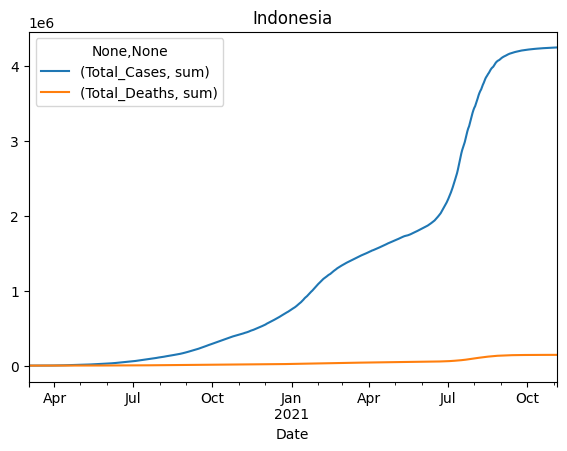

In [8]:
#IDN
ConfirmedCases_date_IDN= data[data['Location_ISO_Code']=='IDN'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_IDN = data[data['Location_ISO_Code']=='IDN'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_IDN= ConfirmedCases_date_IDN.join(fatalities_date_IDN)


plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_IDN.plot(ax=plt.gca(), title='Indonesia')

Text(0, 0.5, 'Confirmed cases')

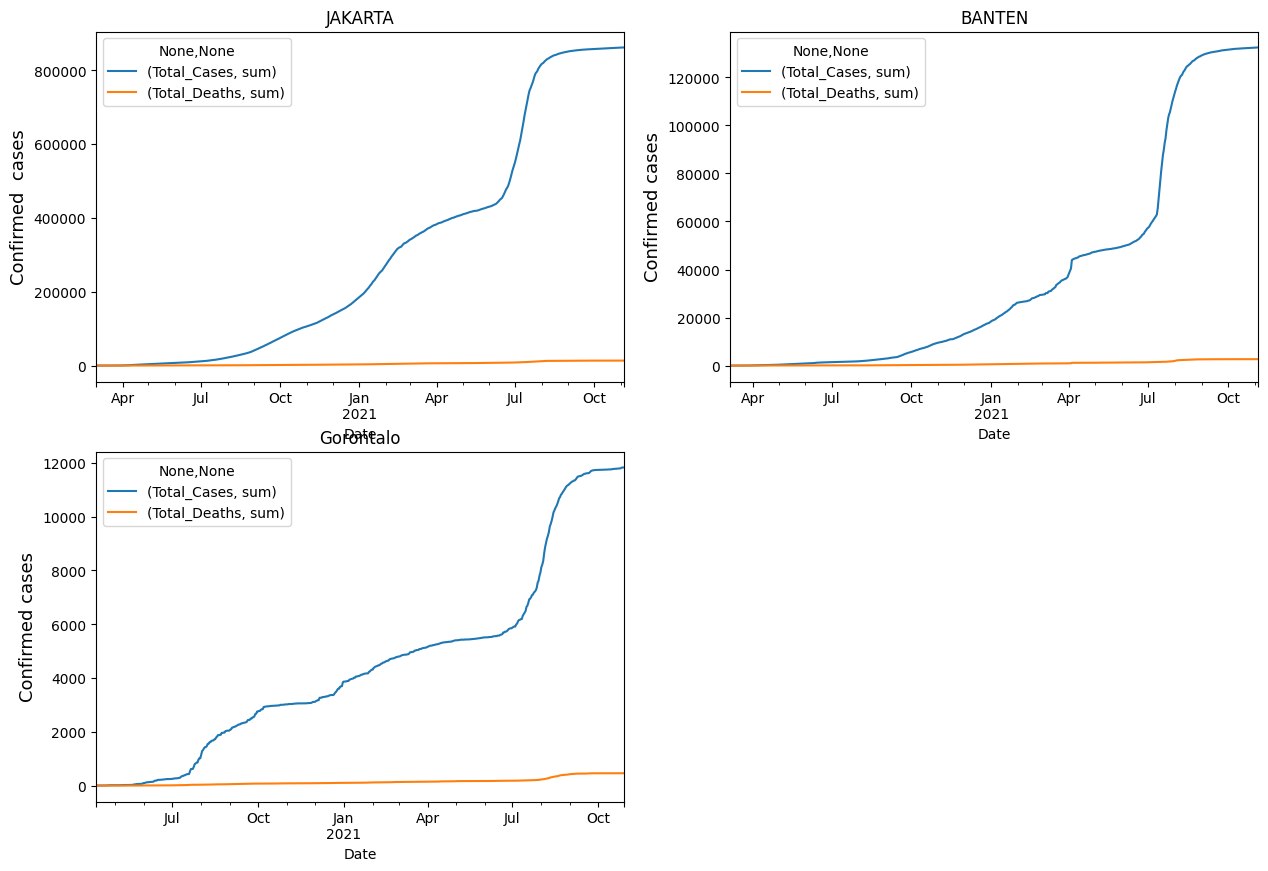

In [9]:
#ID-JK
ConfirmedCases_date_JK= data[data['Location_ISO_Code']=='ID-JK'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_JK = data[data['Location_ISO_Code']=='ID-JK'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_JK = ConfirmedCases_date_JK.join(fatalities_date_JK)


#ID-BT
ConfirmedCases_date_BT= data[data['Location_ISO_Code']=='ID-BT'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_BT = data[data['Location_ISO_Code']=='ID-BT'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_BT = ConfirmedCases_date_BT.join(fatalities_date_BT)


#ID-GO
ConfirmedCases_date_GO= data[data['Location_ISO_Code']=='ID-GO'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_GO = data[data['Location_ISO_Code']=='ID-GO'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_GO = ConfirmedCases_date_GO.join(fatalities_date_GO)


plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_JK.plot(ax=plt.gca(), title='JAKARTA')
plt.ylabel("Confirmed  cases", size=13)


plt.subplot(2, 2, 2)
total_date_BT.plot(ax=plt.gca(), title='BANTEN')
plt.ylabel("Confirmed cases", size=13)


plt.subplot(2, 2, 3)
total_date_GO.plot(ax=plt.gca(), title='Gorontalo')
plt.ylabel("Confirmed cases", size=13)

<Axes: title={'center': 'Daerah Istimewa Yogyakarta'}, xlabel='Date'>

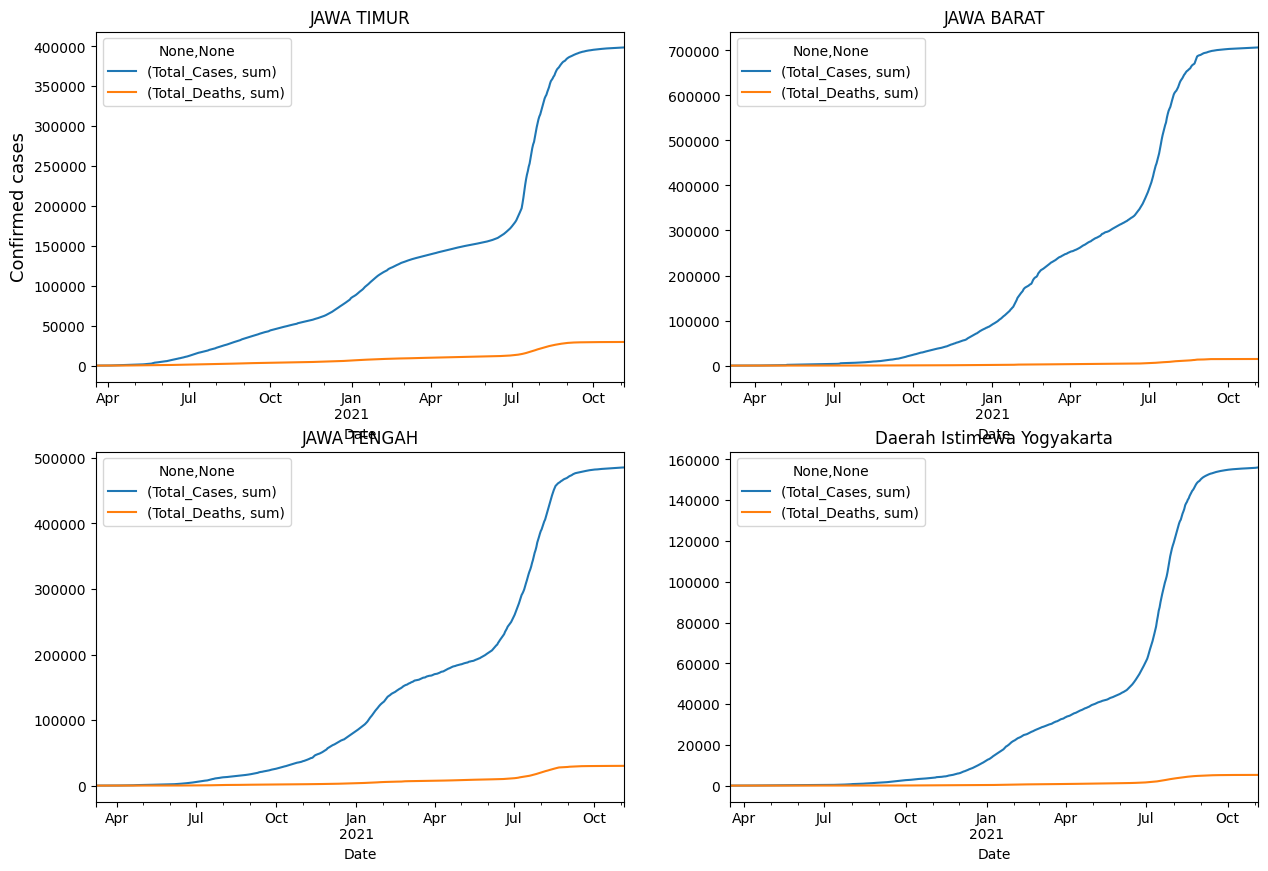

In [10]:
#ID-JI
ConfirmedCases_date_JI= data[data['Location_ISO_Code']=='ID-JI'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_JI = data[data['Location_ISO_Code']=='ID-JI'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_JI = ConfirmedCases_date_JI.join(fatalities_date_JI)


#ID-JB
ConfirmedCases_date_JB= data[data['Location_ISO_Code']=='ID-JB'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_JB = data[data['Location_ISO_Code']=='ID-JB'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_JB = ConfirmedCases_date_JB.join(fatalities_date_JB)


#ID-JT
ConfirmedCases_date_JT= data[data['Location_ISO_Code']=='ID-JT'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_JT = data[data['Location_ISO_Code']=='ID-JT'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_JT = ConfirmedCases_date_JT.join(fatalities_date_JT)


#ID-YO
ConfirmedCases_date_YO= data[data['Location_ISO_Code']=='ID-YO'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_YO = data[data['Location_ISO_Code']=='ID-YO'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_YO = ConfirmedCases_date_YO.join(fatalities_date_YO)

plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_JI.plot(ax=plt.gca(), title='JAWA TIMUR')
plt.ylabel("Confirmed cases", size=13)


plt.subplot(2, 2, 2)
total_date_JB.plot(ax=plt.gca(), title='JAWA BARAT')


plt.subplot(2, 2, 3)
total_date_JT.plot(ax=plt.gca(), title='JAWA TENGAH')

plt.subplot(2, 2, 4)
total_date_YO.plot(ax=plt.gca(), title='Daerah Istimewa Yogyakarta')

<Axes: title={'center': 'Bengkulu'}, xlabel='Date'>

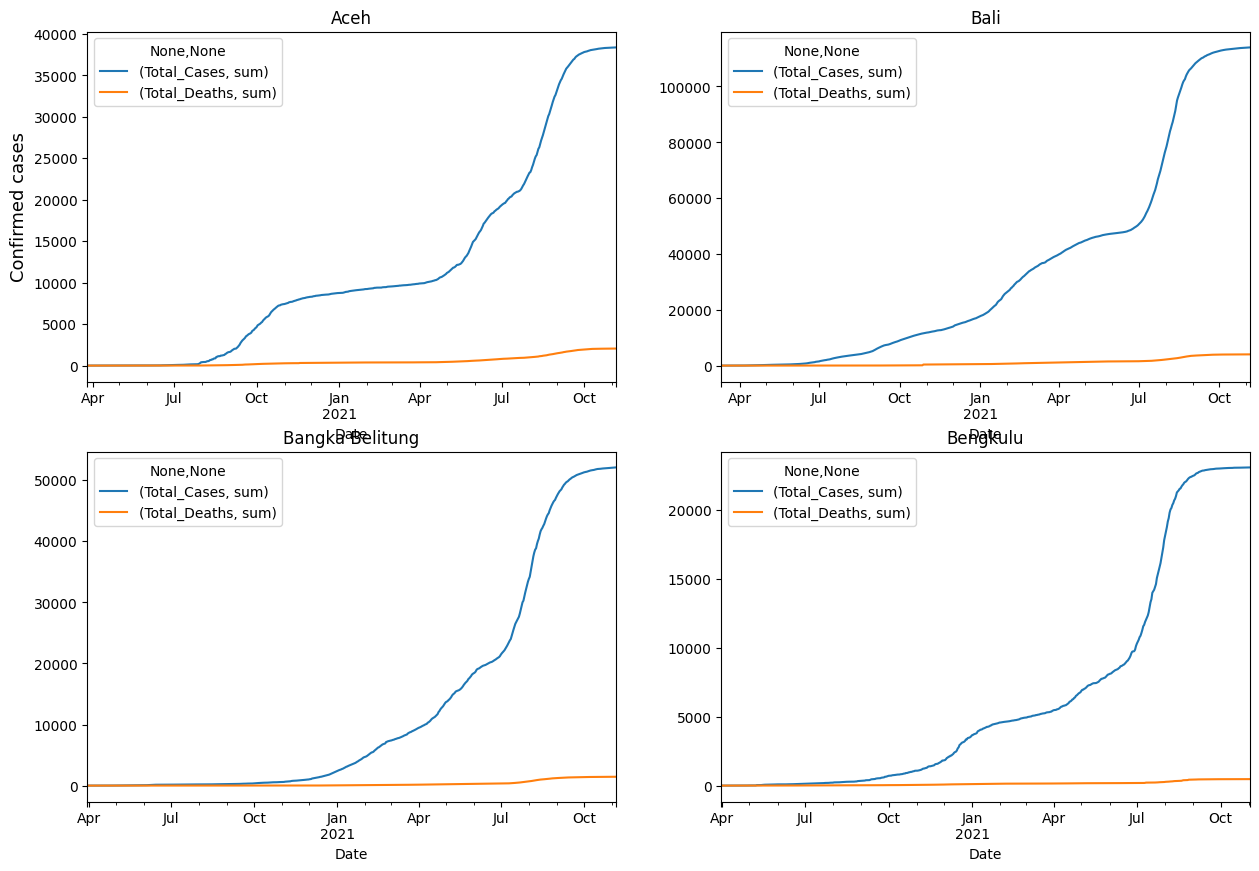

In [11]:
#ID-AC
ConfirmedCases_date_AC= data[data['Location_ISO_Code']=='ID-AC'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_AC = data[data['Location_ISO_Code']=='ID-AC'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_AC = ConfirmedCases_date_AC.join(fatalities_date_AC)


#ID-BA
ConfirmedCases_date_BA= data[data['Location_ISO_Code']=='ID-BA'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_BA = data[data['Location_ISO_Code']=='ID-BA'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_BA = ConfirmedCases_date_BA.join(fatalities_date_BA)


#ID-BB
ConfirmedCases_date_BB= data[data['Location_ISO_Code']=='ID-BB'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_BB = data[data['Location_ISO_Code']=='ID-BB'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_BB = ConfirmedCases_date_BB.join(fatalities_date_BB)


#ID-BE
ConfirmedCases_date_BE= data[data['Location_ISO_Code']=='ID-BE'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_BE = data[data['Location_ISO_Code']=='ID-BE'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_BE = ConfirmedCases_date_BE.join(fatalities_date_BE)

plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_AC.plot(ax=plt.gca(), title='Aceh')
plt.ylabel("Confirmed cases", size=13)


plt.subplot(2, 2, 2)
total_date_BA.plot(ax=plt.gca(), title='Bali')


plt.subplot(2, 2, 3)
total_date_BB.plot(ax=plt.gca(), title='Bangka Belitung')

plt.subplot(2, 2, 4)
total_date_BE.plot(ax=plt.gca(), title='Bengkulu')

<Axes: title={'center': 'Kalimantan Utara'}, xlabel='Date'>

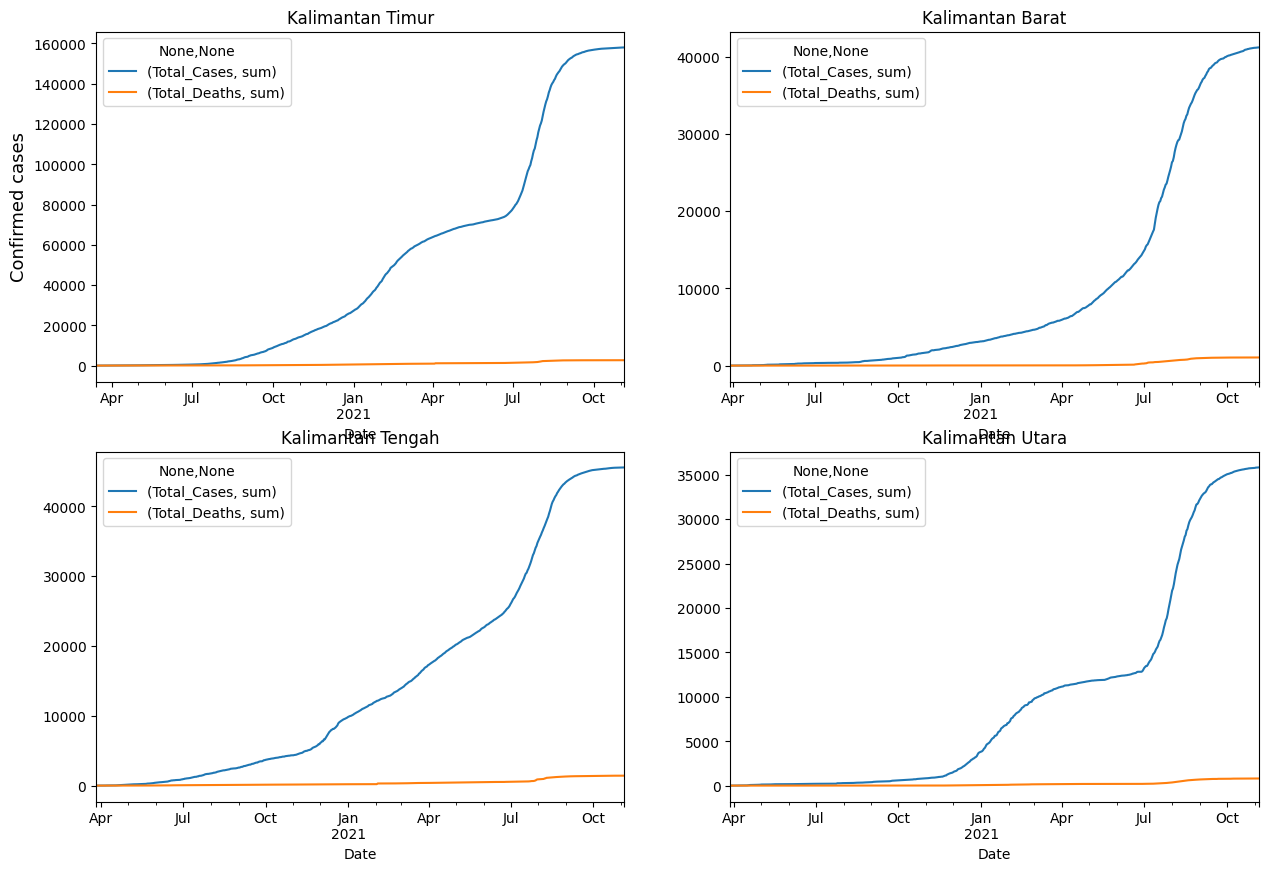

In [12]:
#ID-KI
ConfirmedCases_date_KI= data[data['Location_ISO_Code']=='ID-KI'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KI = data[data['Location_ISO_Code']=='ID-KI'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KI = ConfirmedCases_date_KI.join(fatalities_date_BT)


#ID-KB
ConfirmedCases_date_KB= data[data['Location_ISO_Code']=='ID-KB'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KB = data[data['Location_ISO_Code']=='ID-KB'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KB = ConfirmedCases_date_KB.join(fatalities_date_KB)



#ID-KT
ConfirmedCases_date_KT= data[data['Location_ISO_Code']=='ID-KT'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KT = data[data['Location_ISO_Code']=='ID-KT'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KT = ConfirmedCases_date_KT.join(fatalities_date_KT)

#ID-KU
ConfirmedCases_date_KU= data[data['Location_ISO_Code']=='ID-KU'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KU = data[data['Location_ISO_Code']=='ID-KU'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KU = ConfirmedCases_date_KU.join(fatalities_date_KU)

plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_KI.plot(ax=plt.gca(), title='Kalimantan Timur')
plt.ylabel("Confirmed cases", size=13)

plt.subplot(2, 2, 2)
total_date_KB.plot(ax=plt.gca(), title='Kalimantan Barat')

plt.subplot(2, 2, 3)
total_date_KT.plot(ax=plt.gca(), title='Kalimantan Tengah')

plt.subplot(2, 2, 4)
total_date_KU.plot(ax=plt.gca(), title='Kalimantan Utara')

<Axes: title={'center': 'Kepulauan Riau'}, xlabel='Date'>

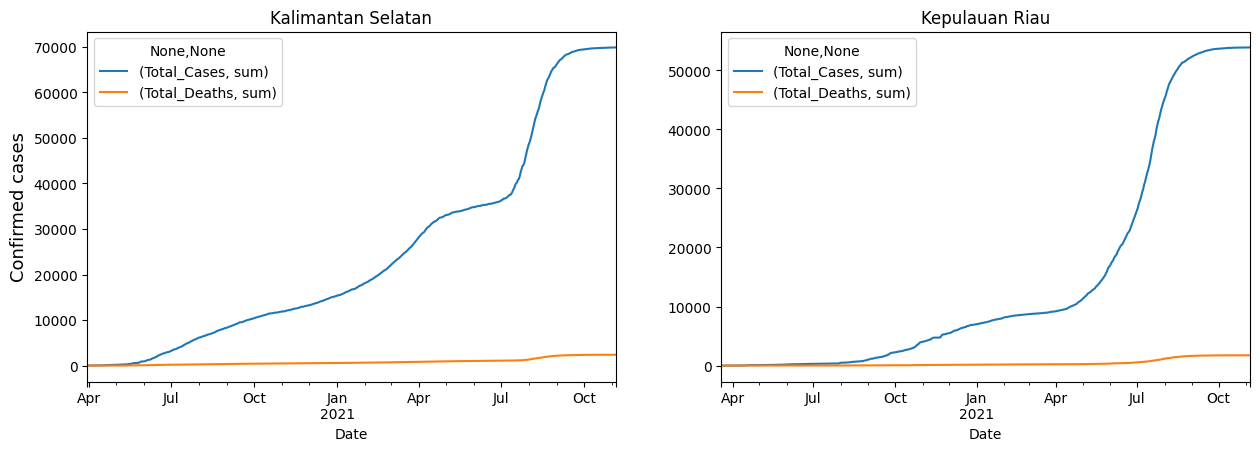

In [13]:
#ID-KS
ConfirmedCases_date_KS= data[data['Location_ISO_Code']=='ID-KS'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KS = data[data['Location_ISO_Code']=='ID-KS'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KS = ConfirmedCases_date_KS.join(fatalities_date_KS)

#ID-KR
ConfirmedCases_date_KR= data[data['Location_ISO_Code']=='ID-KR'].groupby(['Date']).agg({'Total_Cases':['sum']})
fatalities_date_KR = data[data['Location_ISO_Code']=='ID-KR'].groupby(['Date']).agg({'Total_Deaths':['sum']})
total_date_KR = ConfirmedCases_date_KR.join(fatalities_date_KR)






plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
total_date_KS.plot(ax=plt.gca(), title='Kalimantan Selatan')
plt.ylabel("Confirmed cases", size=13)



plt.subplot(2, 2, 2)
total_date_KR.plot(ax=plt.gca(), title='Kepulauan Riau')